First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  

Shape of Dataset: (20640, 9)

Missing Values:
MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64

Intercept: -37.02327770606402

Coefficients:
MedInc: 0.4487
HouseAge: 0.0097
AveRooms: -0.1233
AveBedrms: 0.7831
Popu

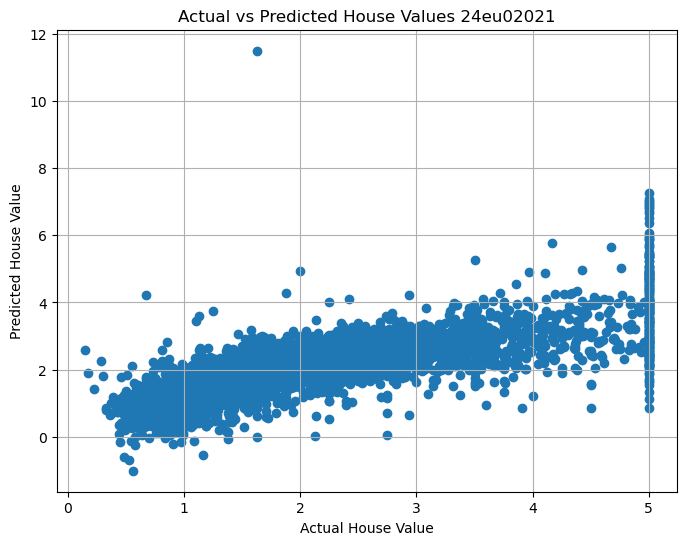

In [1]:
# ==========================================================
# Regression Task on California Housing Dataset
# ==========================================================

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load California Housing Dataset
housing = fetch_california_housing()

# Step 3: Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["MedHouseValue"] = housing.target

# Step 4: Display Dataset
print("First 5 Rows:")
print(df.head())

print("\nShape of Dataset:", df.shape)

# Step 5: Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 6: Separate Features and Target
X = df.drop("MedHouseValue", axis=1)
y = df["MedHouseValue"]

# Step 7: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 8: Create Linear Regression Model
model = LinearRegression()

# Step 9: Train the Model
model.fit(X_train, y_train)

# Step 10: Predict Test Data
y_pred = model.predict(X_test)

# Step 11: Model Coefficients
print("\nIntercept:", model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

# Step 12: Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n===== Model Evaluation =====")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

# Step 13: Actual vs Predicted Values
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(comparison.head(10))

# Step 14: Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values 24eu02021")
plt.grid(True)
plt.show()